In [1]:
# Dependencies Installation
!pip3 install pyspark==2.4.5
!pip3 install matplotlib seaborn pytest

# Import statements

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from pyspark.sql.functions import avg, col,row_number
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer
from datetime import datetime

current_year = datetime.now().year


In [2]:
import logging
import sys

def setup_logger(name: str = "data_pipeline_logger", log_file="pipeline.log"):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)

    # Clear old handlers (important in Jupyter)
    if logger.hasHandlers():
        logger.handlers.clear()

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Console Handler
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)

    # File Handler
    file_handler = logging.FileHandler(log_file)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    logger.propagate = False

    return logger

logger = setup_logger()
logger.info("Logger initialized successfully.")

2026-02-26 19:06:42 | INFO | data_pipeline_logger | Logger initialized successfully.


In [3]:
spark = (
    SparkSession.builder
    .appName("pyspark-assessment")\
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true")\
    .config("spark.sql.shuffle.partitions", "200")\
    .config("spark.sql.autoBroadcastJoinThreshold", 10485760)\
    .getOrCreate()
)

In [4]:
def read_data(spark, file_path, file_format="csv", source="local"):
    """
    Generic read function.
    """
    if source == "cloud":
        logger.info("Reading from Cloud (Placeholder)")
        # Add S3 / cloud configs here if needed
        # Initiate Boto3 to read S3 files
        pass

    file_format = file_format.lower()

    if file_format == "csv":
        df = (
            spark.read
            .format("csv")
            .option("header", True)
            .option("inferSchema", True)
            .option("multiLine", True)
            .option("escape", "\"")
            .load(file_path)
        )
        logger.info("Data loaded successfully. Format: CSV")

    elif file_format == "parquet":
        df = (
            spark.read
            .format("parquet")
            .load(file_path)
        )
        logger.info(f"Data loaded successfully. Format: Parquet")

    else:
        raise ValueError(f"Unsupported file format: {file_format}")

    return df

In [5]:
def write_data(df, output_path, file_format="parquet", target="local", mode="overwrite", **options):
    """
    Generic write function.
    """

    if target == "cloud":
        print("Writing to Cloud (Placeholder)")
        logger.info(f"Writing to Cloud (Placeholder). location: {output_path}")
        # Add S3 required configs
        pass

    file_format = file_format.lower()

    if file_format not in ["csv", "parquet"]:
        raise ValueError(f"Unsupported file format: {file_format}")
        

    writer = df.repartition(spark.sparkContext.defaultParallelism)\
    .write\
    .format(file_format)\
    .mode(mode)

    # Apply format-specific options dynamically
    for key, value in options.items():
        writer = writer.option(key, value)

    writer.save(output_path)
    logger.info("Data Written successfully.")

In [6]:
# Data Exploration Layer

def basic_profile(df):
    """
    Prints schema and basic stats.
    """
    df.printSchema()
    df.describe().show()
    

def detect_column_types(df):
    numerical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType, FloatType))]
    categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    
    print("Numerical Columns:", numerical_cols)
    print("Categorical Columns:", categorical_cols)
    
    return numerical_cols, categorical_cols



In [7]:
# Data Sanitation Layer

def sanitize_column_names(df):

    new_columns = []

    for col_name in df.columns:
        # Replace spaces with underscore
        new_col = col_name.replace(" ", "_")

        # Remove special characters
        new_col = re.sub(r"[^\w]", "", new_col)

        # Convert to lowercase
        new_col = new_col.lower()

        new_columns.append(new_col)

    # Rename columns
    for old, new in zip(df.columns, new_columns):
        df = df.withColumnRenamed(old, new)
        
    logger.info(f"Data Sanitized successfully. Record count: {df.count()}")    

    return df

In [8]:
# Data Cleaning Layer

def clean_data(df):
    """
    Basic cleaning:
    - Drop duplicates
    - null salary handling
    """
    df = df.dropDuplicates()
    
    df = df.fillna({
        "salary_range_from": 0,
        "salary_range_to": 0
    })
    logger.info(f"Data Cleaned successfully. Record count: {df.count()}")
    
    return df

def add_avg_salary(df):
    return df.withColumn(
        "avg_salary",
        (col("salary_range_from") + col("salary_range_to")) / 2
    )


In [9]:
# Feature 
def feature_engineering(df):
    
    df = df.withColumn(
    "description_length",
    length(col("job_description"))
    )
    
    df.show(truncate=False)
    
    df = df.withColumn(
    "experience_bucket",
    when(col("level").like("%Senior%"), "Senior")
    .when(col("level").like("%Mid%"), "Mid")
    .otherwise("Junior")
    )
    
    df.show(truncate=False)
    
    df = df.withColumn(
    "is_remote",
    col("job_description").contains("remote").cast("int")
    )
    
    df.show(truncate=False)
    
    logger.info(f"FE Done. Record count: {df.count()}")
    return df

In [10]:
# Removal of other columns 

def remove_irrelevant_features(df, drop_cols=None):
    """
    Removes specified columns from DataFrame.
    """

    if drop_cols is None:
        drop_cols = []

    # Keep only columns that exist in dataframe
    existing_drop_cols = [c for c in drop_cols if c in df.columns]
    
    logger.info(f"Columns removed: {existing_drop_cols}")

    return df.drop(*existing_drop_cols)


In [11]:
## KPI 

def top_10_job_categories(df):
    return df.groupBy("job_category") \
        .count() \
        .orderBy(desc("count")) \
        .limit(10)


def salary_distribution(df):
    return df.groupBy("job_category") \
        .agg(
            avg(
                (col("salary_range_from") + col("salary_range_to")) / 2
            ).alias("avg_salary")
        )

def degree_salary_correlation(df):

    df = df.withColumn(
        "degree_numeric",
        when(col("degree_required") == "High School", 1)
        .when(col("degree_required") == "Bachelor", 2)
        .when(col("degree_required") == "Master", 3)
        .when(col("degree_required") == "PhD", 4)
        .otherwise(None)
    )

    return df.stat.corr("avg_salary", "degree_numeric")

def highest_salary_per_agency(df):
    agency_salary_spec = Window.partitionBy("Agency").orderBy(desc("avg_salary"))
    
    highest_salary_per_agency = (
    df.withColumn("rank", row_number().over(agency_salary_spec))
      .filter(col("rank") == 1)
      .drop("rank")
    )
    
    return highest_salary_per_agency

def avg_salary_last_2_years(df, current_year):
    
    df = df.withColumn("posting_date", col("posting_date").cast("date"))
    
    df_last_2_years = df.filter(
    datediff(current_date(), col("posting_date")) <= 730
    )
    
    avg_salary_last_2_years = (
    df_last_2_years.groupBy("Agency")
                   .avg("avg_salary")
    )

    return avg_salary_last_2_years

def highest_paid_skills(df):
    return df.groupBy("job_category") \
        .agg(avg("avg_salary").alias("avg_salary")) \
        .orderBy(desc("avg_salary"))

def visualize_top_categories(df_spark):
    pdf = df_spark.toPandas()
    
    plt.figure(figsize=(10,5))
    sns.barplot(data=pdf, x="job_category", y="count")
    plt.xticks(rotation=45)
    plt.show()


In [12]:
def main_pipeline(
    spark,
    file_path,
    input_format="csv",
    output_path="output/processed_jobs",
    output_format="parquet",
    drop_columns=None
):
    """
    Main ETL Pipeline
    """

    try:
        print("$tarting Pipeline...")

        # 1 Read
        df = read_data(spark, file_path, file_format=input_format)
        print("Data Read Completed")
        logger.info(f"Data loaded successfully. Record count: {df.count()}")

        # 2 Profile
        basic_profile(df)
        detect_column_types(df)
        
        # 3 Sanitize column names
        df = sanitize_column_names(df)

        # 4 Clean
        df = clean_data(df)
        print("Data Cleaning Completed")
        
        # 5 Profile post Sanitation
        basic_profile(df)
        detect_column_types(df)
        
        df = add_avg_salary(df)  
        
        # 6 Caching df for performance
        df = df.cache()
        df.count()

        # 6 Feature Engineering
        df = feature_engineering(df)
        print("✅ Feature Engineering Completed")

        # 6 Remove Features
        df = remove_irrelevant_features(df, drop_cols=drop_columns)
        print("✅ Feature Removal Completed")
        
        # 7 Write Processed Data
        write_data(df, output_path, file_format=output_format)
        print("✅ Data Written Successfully")

        # 8 KPI
        
        fe = feature_engineering(df)
        fe.show(truncate=False)
        
        
        top10 = top_10_job_categories(df)
        top10.show(truncate=False)
        
        sd = salary_distribution(df)
        sd.show(truncate=False)
        
        dsc = degree_salary_correlation
        print("Degree vs Salary Correlation:", dsc)
        
        hspa = highest_salary_per_agency(df)
        hspa.show(truncate=False)
        
        asl2 = avg_salary_last_2_years(df , current_year)
        asl2.show(truncate=False)
        
        hps = highest_paid_skills(df)
        hps.show(truncate=False)
        

        # 9 Visualization
        visualize_top_categories(top10)
        logger.info("Data Visualisation successful.")

        print("Pipeline Completed Successfully!")

    except Exception as e:
        print("########## Pipeline Failed ##########")
        print(str(e))
        raise

In [13]:
drop_cols = ["job_id", "title_code_no"]
file_location="data/nyc-jobs.csv"
file_format="csv"
output_location="output/processed_jobs"
output_format="parquet"

$tarting Pipeline...
2026-02-26 19:06:48 | INFO | data_pipeline_logger | Data loaded successfully. Format: CSV
Data Read Completed
2026-02-26 19:06:49 | INFO | data_pipeline_logger | Data loaded successfully. Record count: 2946
root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirement

+------+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

✅ Feature Engineering Completed
2026-02-26 19:06:57 | INFO | data_pipeline_logger | Columns removed: ['job_id', 'title_code_no']
✅ Feature Removal Completed
2026-02-26 19:06:58 | INFO | data_pipeline_logger | Data Written successfully.
✅ Data Written Successfully
+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+------------------------------+------------+-------------+-------------------------------------------------------------+------------------------------+-----+-----------------------------------------------------------------------------------------------------------------------------+--------------------------+-----------------+---------------+----------------+------------------------------+------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+-----------------------------------------+-----+
|job_category                             |count|
+-----------------------------------------+-----+
|Engineering, Architecture, & Planning    |497  |
|Technology, Data & Innovation            |312  |
|Legal Affairs                            |224  |
|Public Safety, Inspections, & Enforcement|179  |
|Building Operations & Maintenance        |177  |
|Finance, Accounting, & Procurement       |168  |
|Administration & Human Resources         |131  |
|Constituent Services & Community Programs|129  |
|Health                                   |125  |
|Policy, Research & Analysis              |124  |
+-----------------------------------------+-----+

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|job_category                                                                      

+------+---------------+
|Agency|avg(avg_salary)|
+------+---------------+
+------+---------------+

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+
|job_category                                                                                                                                                                                             |avg_salary       |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------+
|Administration & Human Resources Finance, Accounting, & Procurement Building Operations & Maintenance                                                                                                    |218587.0         |
|Engineerin

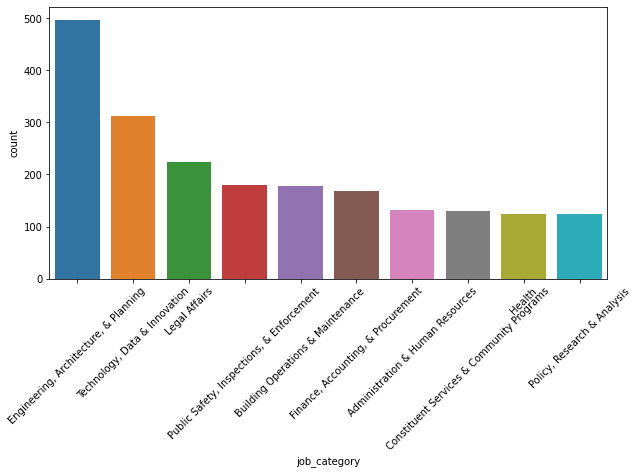

2026-02-26 19:07:01 | INFO | data_pipeline_logger | Data Visualisation successful.
Pipeline Completed Successfully!


In [14]:

main_pipeline(
    spark,
    file_path=file_location,
    input_format=file_format,
    output_path=output_location,
    output_format=output_format,
    drop_columns=drop_cols
)

In [15]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

expected_schema = StructType([
    StructField("job_id", StringType(), False),
    StructField("job_title", StringType(), True),
    StructField("category", StringType(), True),
    StructField("salary", DoubleType(), True),
    StructField("agency", StringType(), True),
    StructField("degree_required", StringType(), True)
])

logger.info("Applying strict schema validation...")

try:
    df = spark.read.csv(
        file_location,
        header=True,
        schema=expected_schema
    )
    logger.info("Schema validation passed.")
except Exception as e:
    logger.error("Schema validation failed.")
    raise

2026-02-26 19:07:01 | INFO | data_pipeline_logger | Applying strict schema validation...
2026-02-26 19:07:01 | INFO | data_pipeline_logger | Schema validation passed.


In [16]:
spark.stop()

In [17]:
with open("pipeline.log", "r") as f:
    logs = f.read()

print(logs)

2026-02-26 18:44:35 | INFO | data_pipeline_logger | Logger initialized successfully.
2026-02-26 18:44:41 | INFO | data_pipeline_logger | Data loaded successfully. Format: CSV
2026-02-26 18:44:42 | INFO | data_pipeline_logger | Data loaded successfully. Record count: 2946
2026-02-26 18:44:44 | INFO | data_pipeline_logger | Data Sanitized successfully. Record count: 2946
2026-02-26 18:44:46 | INFO | data_pipeline_logger | Data Cleaned successfully. Record count: 2915
2026-02-26 18:44:50 | INFO | data_pipeline_logger | FE Done. Record count: 2915
2026-02-26 18:44:50 | INFO | data_pipeline_logger | Columns removed: ['job_id', 'title_code_no']
2026-02-26 18:44:51 | INFO | data_pipeline_logger | Data Written successfully.
2026-02-26 18:44:52 | INFO | data_pipeline_logger | FE Done. Record count: 2915
2026-02-26 18:44:54 | INFO | data_pipeline_logger | Data Visualisation successful.
2026-02-26 18:44:54 | INFO | data_pipeline_logger | Applying strict schema validation...
2026-02-26 18:44:54 | 

In [18]:
# ==========================================
# KPI UNIT TEST 
# ==========================================

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from datetime import datetime
import builtins 

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("KPI-Test") \
    .getOrCreate()

data = [
    ("Tech", "Agency1", 50000, 70000, "Bachelor", "2024-01-01"),
    ("Tech", "Agency1", 80000, 100000, "Master", "2023-06-01"),
    ("HR", "Agency2", 40000, 50000, "High School", "2022-01-01"),
    ("HR", "Agency2", 60000, 70000, "Bachelor", "2024-05-01"),
    ("Finance", "Agency3", 90000, 110000, "PhD", "2024-02-01"),
]

columns = [
    "job_category",
    "Agency",
    "salary_range_from",
    "salary_range_to",
    "degree_required",
    "posting_date"
]

df = spark.createDataFrame(data, columns)

df = df.withColumn(
    "avg_salary",
    (F.col("salary_range_from") + F.col("salary_range_to")) / 2
)

# ================================
# TEST CASES
# ================================

print("Running KPI Tests...\n")

# 1 Top categories
top_categories = top_10_job_categories(df).collect()
category_counts = {r["job_category"]: r["count"] for r in top_categories}

assert category_counts["Tech"] == 2
assert category_counts["HR"] == 2
print("Top_10_job_categories PASSED")

# 2 Salary distribution
salary_dist = salary_distribution(df).collect()
salary_dict = {r["job_category"]: r["avg_salary"] for r in salary_dist}

assert builtins.abs(salary_dict["Tech"] - 75000) < 0.01
assert builtins.abs(salary_dict["Finance"] - 100000) < 0.01
print("Salary_distribution PASSED")

# 4 Correlation
corr = degree_salary_correlation(df)
assert isinstance(corr, float)
assert corr > 0
print("Degree_salary_correlation PASSED")

# 4 Highest salary per agency
hspa = highest_salary_per_agency(df).collect()
agency_salary = {r["Agency"]: r["avg_salary"] for r in hspa}

assert agency_salary["Agency1"] == 90000
assert agency_salary["Agency3"] == 100000
print("Highest_salary_per_agency PASSED")

# 5 Avg salary last 2 years
current_year = datetime.now().year
asl2 = avg_salary_last_2_years(df, current_year).collect()
assert len(asl2) > 0
print("Avg_salary_last_2_years PASSED")

# 6 Highest paid skills
highest_skills = highest_paid_skills(df).collect()
assert highest_skills[0]["job_category"] == "Finance"
print("Highest_paid_skills PASSED")

print("\nALL TESTS PASSED SUCCESSFULLY")

spark.stop()

Running KPI Tests...

Top_10_job_categories PASSED
Salary_distribution PASSED
Degree_salary_correlation PASSED
Highest_salary_per_agency PASSED
Avg_salary_last_2_years PASSED
Highest_paid_skills PASSED

ALL TESTS PASSED SUCCESSFULLY
